# Quiz1: 彩色影像--灰階影像

In [1]:
from pathlib import Path
import cv2

input_path = Path("/Users/shen/Project/MMIP/week1/Data/富山多拉Ａ夢圖片.png")
output_path = input_path.with_name("富山多拉Ａ夢圖片_灰階.png")

image = cv2.imread(str(input_path))
if image is None:
    raise FileNotFoundError(f"找不到圖片：{input_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2.imwrite(str(output_path), gray)

print(f"已儲存：{output_path}")

已儲存：/Users/shen/Project/MMIP/week1/Data/富山多拉Ａ夢圖片_灰階.png


In [2]:
from pathlib import Path
import cv2
import numpy as np

input_path = Path("/Users/shen/Project/MMIP/week1/Data/富山多拉Ａ夢圖片.png")
output_path = input_path.with_name("富山多拉Ａ夢圖片_NumPy灰階.png")

image = cv2.imread(str(input_path), cv2.IMREAD_COLOR)
if image is None:
    raise FileNotFoundError(f"讀不到圖片：{input_path}")

blue = image[:, :, 0].astype(np.float32)
green = image[:, :, 1].astype(np.float32)
red = image[:, :, 2].astype(np.float32)

gray = 0.114 * blue + 0.587 * green + 0.299 * red
gray = np.rint(gray).clip(0, 255).astype(np.uint8)

if not cv2.imwrite(str(output_path), gray):
    raise OSError(f"無法儲存：{output_path}")

print(f"已儲存：{output_path}")

已儲存：/Users/shen/Project/MMIP/week1/Data/富山多拉Ａ夢圖片_NumPy灰階.png


# opencv vs numpy

Matplotlib is building the font cache; this may take a moment.


重複次數：100 次
NumPy 平均時間：  3.3378 毫秒／次
OpenCV 平均時間：0.0753 毫秒／次
兩張圖片完全相同：False
不同的像素：46 / 540813 個
不同像素比例：0.01%
平均像素差異：0.0001
最大像素差異：1


/var/folders/6w/c77pnk3s1dq_h5wpbc4z3_4c0000gp/T/ipykernel_78160/3654425816.py:87: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6w/c77pnk3s1dq_h5wpbc4z3_4c0000gp/T/ipykernel_78160/3654425816.py:87: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6w/c77pnk3s1dq_h5wpbc4z3_4c0000gp/T/ipykernel_78160/3654425816.py:87: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6w/c77pnk3s1dq_h5wpbc4z3_4c0000gp/T/ipykernel_78160/3654425816.py:87: UserWarning: Glyph 30064 (\N{CJK UNIFIED IDEOGRAPH-7570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/shen/anaconda3/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)

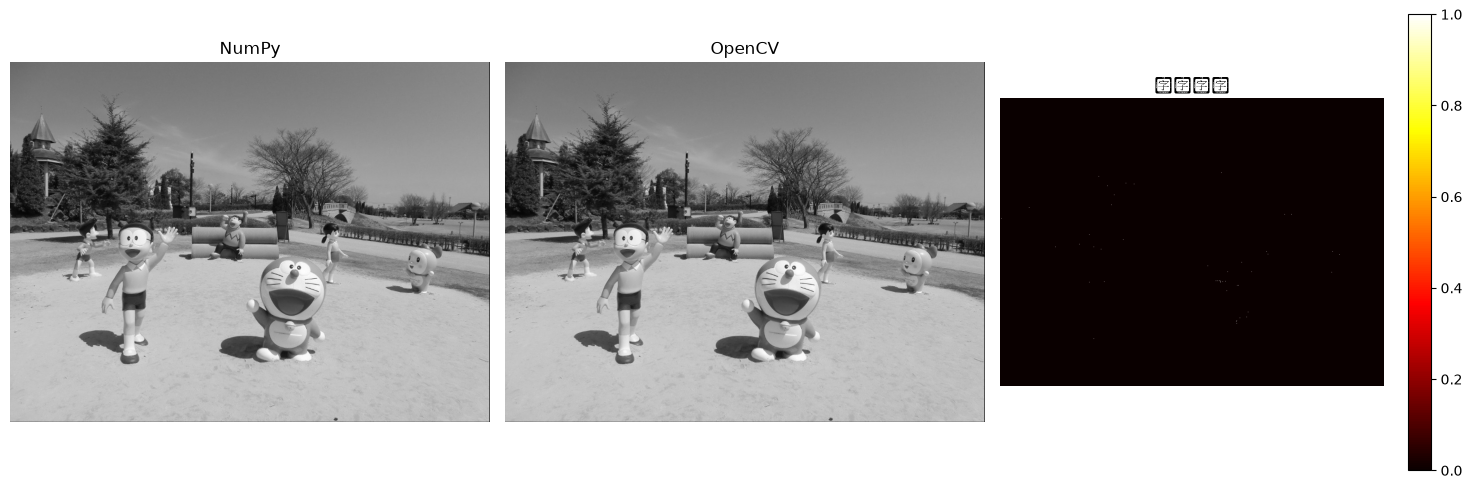

In [3]:
from pathlib import Path
from time import perf_counter

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 讀取圖片
input_path = Path("/Users/shen/Project/MMIP/week1/Data/富山多拉Ａ夢圖片.png")
image = cv2.imread(str(input_path), cv2.IMREAD_COLOR)

if image is None:
    raise FileNotFoundError(f"找不到圖片：{input_path}")

# 2. NumPy 自行實作灰階轉換
def gray_by_numpy(img):
    img_float = img.astype(np.float32)

    blue = img_float[:, :, 0]
    green = img_float[:, :, 1]
    red = img_float[:, :, 2]

    gray = 0.114 * blue + 0.587 * green + 0.299 * red
    return np.rint(gray).clip(0, 255).astype(np.uint8)

# 3. OpenCV 灰階轉換
def gray_by_opencv(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 4. 重複 N 次，計算每次平均花多少毫秒
def average_time_ms(function, img, n):
    start = perf_counter()

    for _ in range(n):
        function(img)

    end = perf_counter()
    return (end - start) * 1000 / n

N = 100

# 先各執行幾次，減少第一次執行造成的影響
for _ in range(5):
    gray_by_numpy(image)
    gray_by_opencv(image)

numpy_ms = average_time_ms(gray_by_numpy, image, N)
opencv_ms = average_time_ms(gray_by_opencv, image, N)

# 5. 取得結果，逐像素比較
numpy_gray = gray_by_numpy(image)
opencv_gray = gray_by_opencv(image)

# 先轉成較大的整數型別，避免 uint8 相減時產生錯誤結果
difference = np.abs(
    numpy_gray.astype(np.int16) - opencv_gray.astype(np.int16)
)

total_pixels = difference.size
different_pixels = np.count_nonzero(difference)

print(f"重複次數：{N} 次")
print(f"NumPy 平均時間：  {numpy_ms:.4f} 毫秒／次")
print(f"OpenCV 平均時間：{opencv_ms:.4f} 毫秒／次")
print(f"兩張圖片完全相同：{np.array_equal(numpy_gray, opencv_gray)}")
print(f"不同的像素：{different_pixels} / {total_pixels} 個")
print(f"不同像素比例：{different_pixels / total_pixels:.2%}")
print(f"平均像素差異：{difference.mean():.4f}")
print(f"最大像素差異：{difference.max()}")

# 6. 顯示兩張灰階圖和差異圖
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(numpy_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("NumPy")

axes[1].imshow(opencv_gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("OpenCV")

im = axes[2].imshow(difference, cmap="hot")
axes[2].set_title("像素差異")
fig.colorbar(im, ax=axes[2])

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Quiz2: Histogram Equalization


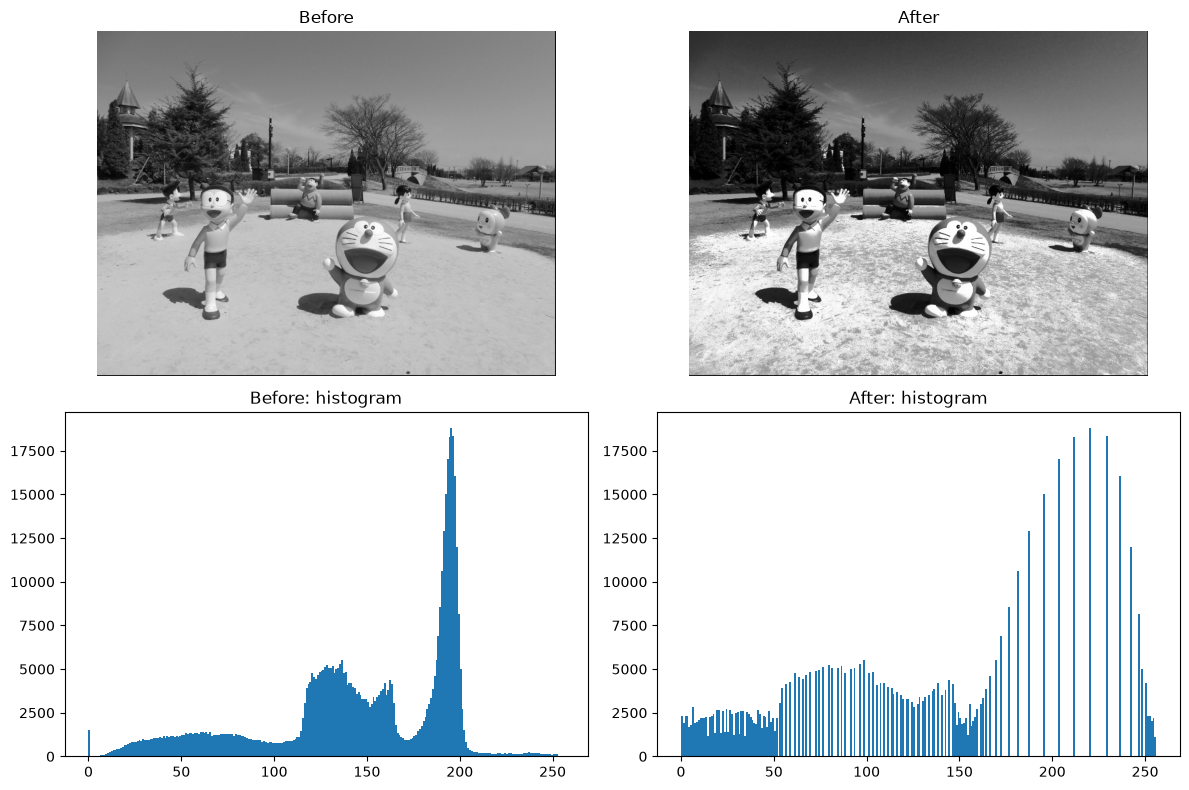

已儲存：/Users/shen/Project/MMIP/week1/Data/富山多拉Ａ夢圖片_直方圖等化.png


In [4]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

input_path = Path("/Users/shen/Project/MMIP/week1/Data/富山多拉Ａ夢圖片.png")
output_path = input_path.with_name("富山多拉Ａ夢圖片_直方圖等化.png")

# 讀取照片並轉成灰階
image = cv2.imread(str(input_path), cv2.IMREAD_COLOR)
if image is None:
    raise FileNotFoundError(f"找不到圖片：{input_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 進行直方圖等化
equalized = cv2.equalizeHist(gray)
cv2.imwrite(str(output_path), equalized)

# 比較影像與亮度分布
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Before")
axes[0, 1].imshow(equalized, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("After")

for ax in axes[0]:
    ax.axis("off")

axes[1, 0].hist(gray.ravel(), bins=256, range=(0, 256))
axes[1, 0].set_title("Before: histogram")

axes[1, 1].hist(equalized.ravel(), bins=256, range=(0, 256))
axes[1, 1].set_title("After: histogram")

plt.tight_layout()
plt.show()

print(f"已儲存：{output_path}")

NumPy 平均時間：  2.115 毫秒／次
OpenCV 平均時間：0.809 毫秒／次
處理前亮度標準差：50.64
NumPy 處理後標準差：74.78
OpenCV 處理後標準差：74.78
不同像素數：0 / 540813
最大像素差異：0


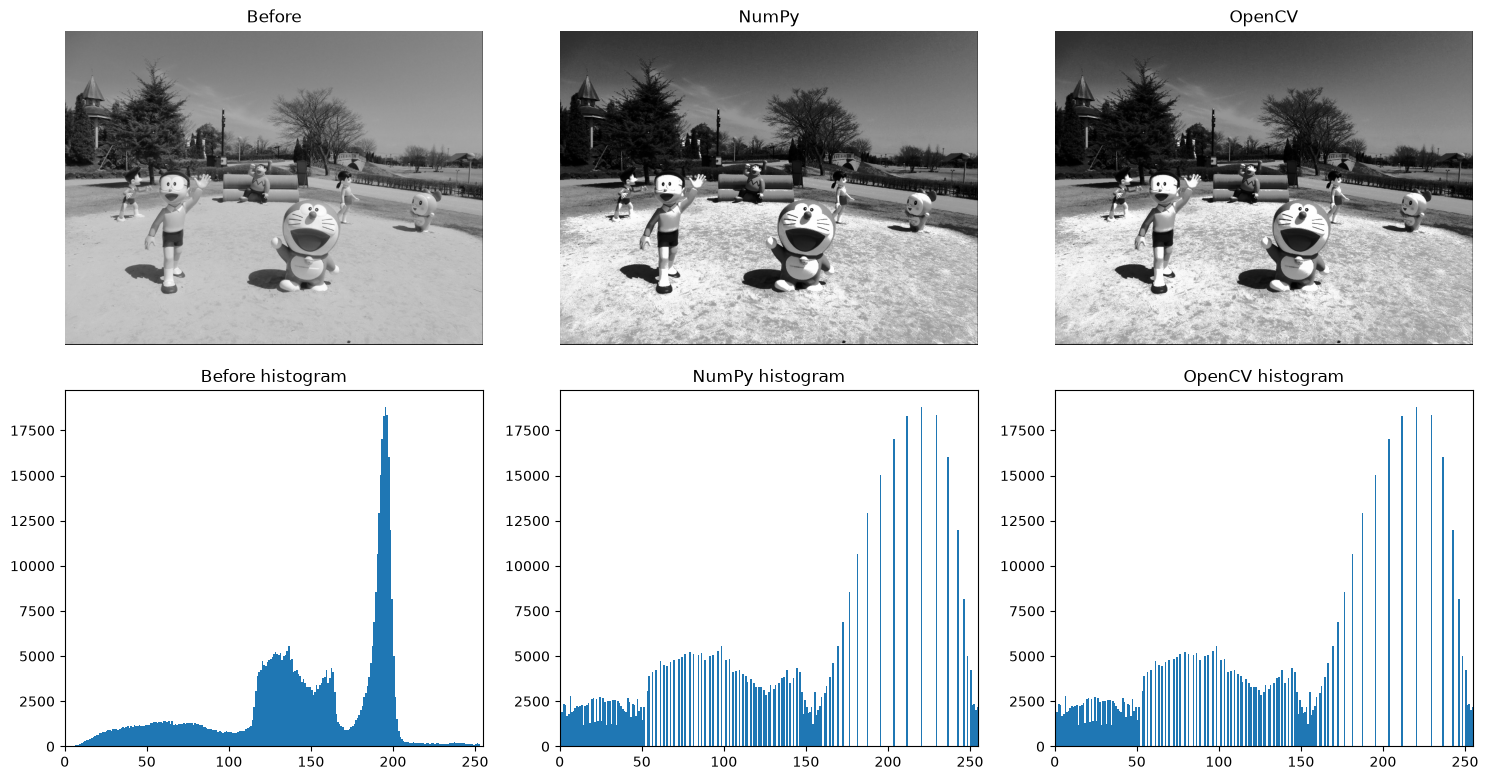

In [7]:
from pathlib import Path
from time import perf_counter

import cv2
import numpy as np
import matplotlib.pyplot as plt

input_path = Path("/Users/shen/Project/MMIP/week1/Data/富山多拉Ａ夢圖片.png")

color = cv2.imread(str(input_path), cv2.IMREAD_COLOR)
if color is None:
    raise FileNotFoundError(f"找不到圖片：{input_path}")

gray = cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)

def equalize_numpy(img):
    # 統計亮度 0～255 各有多少像素
    hist = np.bincount(img.ravel(), minlength=256)

    # 累加：例如亮度 100 的值，代表亮度 0～100 的像素總數
    cdf = hist.cumsum()
    cdf_min = cdf[hist > 0][0]

    # 如果整張圖只有一種亮度，就維持原樣
    if cdf_min == img.size:
        return img.copy()

    # 建立舊亮度 → 新亮度的對照表
    lut = (cdf - cdf_min) * 255 / (img.size - cdf_min)
    lut = np.rint(lut).clip(0, 255).astype(np.uint8)

    return lut[img]

def equalize_opencv(img):
    return cv2.equalizeHist(img)

def average_time_ms(function, img, n):
    start = perf_counter()
    for _ in range(n):
        function(img)
    return (perf_counter() - start) * 1000 / n

# 先執行幾次，減少第一次執行的影響
for _ in range(5):
    equalize_numpy(gray)
    equalize_opencv(gray)

N = 100
numpy_ms = average_time_ms(equalize_numpy, gray, N)
opencv_ms = average_time_ms(equalize_opencv, gray, N)

numpy_result = equalize_numpy(gray)
opencv_result = equalize_opencv(gray)

# 先轉成 int16 再相減，避免 uint8 的數值問題
difference = np.abs(
    numpy_result.astype(np.int16) - opencv_result.astype(np.int16)
)

print(f"NumPy 平均時間：  {numpy_ms:.3f} 毫秒／次")
print(f"OpenCV 平均時間：{opencv_ms:.3f} 毫秒／次")
print(f"處理前亮度標準差：{gray.std():.2f}")
print(f"NumPy 處理後標準差：{numpy_result.std():.2f}")
print(f"OpenCV 處理後標準差：{opencv_result.std():.2f}")
print(f"不同像素數：{np.count_nonzero(difference)} / {difference.size}")
print(f"最大像素差異：{difference.max()}")

# 比較影像和直方圖
images = [gray, numpy_result, opencv_result]
titles = ["Before", "NumPy", "OpenCV"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i in range(3):
    axes[0, i].imshow(images[i], cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(titles[i])
    axes[0, i].axis("off")

    axes[1, i].hist(images[i].ravel(), bins=256, range=(0, 256))
    axes[1, i].set_title(f"{titles[i]} histogram")
    axes[1, i].set_xlim(0, 255)

plt.tight_layout()
plt.show()

# Quiz 3：梯形校正與透視轉換

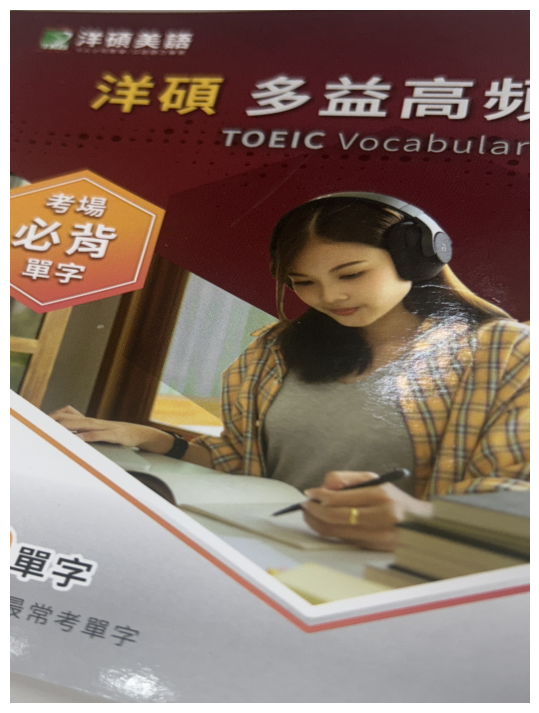

已儲存：/Users/shen/Project/MMIP/week1/Data/陽朔英文_透視校正.png


In [8]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

input_path = Path("/Users/shen/Project/MMIP/week1/Data/陽朔英文.jpg")
output_path = input_path.with_name("陽朔英文_透視校正.png")

image = cv2.imread(str(input_path), cv2.IMREAD_COLOR)
if image is None:
    raise FileNotFoundError(f"找不到圖片：{input_path}")

# 照順序指定：左上、右上、右下、左下
source_points = np.float32([
    [1560,  724],
    [3000, 1152],
    [1820, 3640],
    [ 120, 3160],
])

width, height = 1800, 2400
target_points = np.float32([
    [0,         0],
    [width - 1, 0],
    [width - 1, height - 1],
    [0,         height - 1],
])

matrix = cv2.getPerspectiveTransform(source_points, target_points)
corrected = cv2.warpPerspective(image, matrix, (width, height))

cv2.imwrite(str(output_path), corrected)

plt.figure(figsize=(7, 9))
plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(f"已儲存：{output_path}")

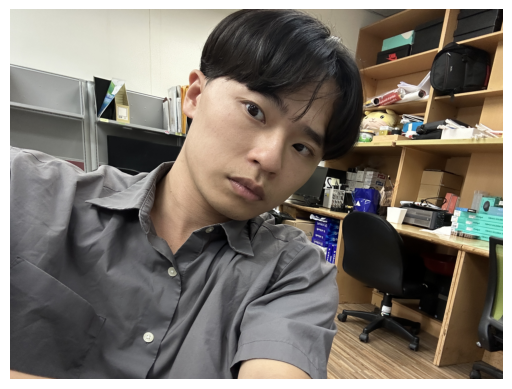

已儲存：/Users/shen/Project/MMIP/week1/Data/沈哥自拍照_透視變換.png


In [10]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

input_path = Path("/Users/shen/Project/MMIP/week1/Data/沈哥自拍照.jpg")
output_path = input_path.with_name("沈哥自拍照_透視變換.png")

image = cv2.imread(str(input_path))
if image is None:
    raise FileNotFoundError(input_path)

# 順序：左上、右上、右下、左下
source_points = np.float32([
    [ 400,  150],
    [3700,    0],
    [3900, 2800],
    [   0, 3000],
])

width, height = 3200, 2400
target_points = np.float32([
    [0,         0],
    [width - 1, 0],
    [width - 1, height - 1],
    [0,         height - 1],
])

matrix = cv2.getPerspectiveTransform(source_points, target_points)
result = cv2.warpPerspective(image, matrix, (width, height))

cv2.imwrite(str(output_path), result)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(f"已儲存：{output_path}")

In [ ]:

import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("/Users/shen/Project/MMIP/week1/Data/Google Lego.jpg")
clicked = []

fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax.set_title("依序點：左上、右上、右下、左下")

def on_click(event):
    if event.inaxes != ax or len(clicked) >= 4:
        return

    x = round(event.xdata)
    y = round(event.ydata)
    clicked.append([x, y])

    ax.plot(x, y, "ro")
    ax.text(x + 20, y + 20, str(len(clicked)), color="red")
    fig.canvas.draw_idle()
    print(f"第 {len(clicked)} 點：[{x}, {y}]")

fig.canvas.mpl_connect("button_press_event", on_click)
plt.show()

In [ ]:
from pathlib import Path
import cv2
import numpy as np
from IPython.display import display, Image

input_path = Path("/Users/shen/Project/MMIP/week1/Data/Google Lego.jpg")
output_path = input_path.with_name("Google Lego_透視校正.png")

image = cv2.imread(str(input_path))
if image is None:
    raise FileNotFoundError(f"找不到圖片：{input_path}")

source_points = np.float32([
    [1460,  624],  # 左上
    [2910, 1136],  # 右上
    [1850, 3450],  # 右下
    [ 160, 2490],  # 左下
])

width, height = 1800, 2400
target_points = np.float32([
    [0, 0],
    [width - 1, 0],
    [width - 1, height - 1],
    [0, height - 1],
])

matrix = cv2.getPerspectiveTransform(source_points, target_points)
result = cv2.warpPerspective(image, matrix, (width, height))

cv2.imwrite(str(output_path), result)
print(f"已儲存：{output_path}")
display(Image(filename=str(output_path), width=450))